In [8]:
import csv
import random
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np


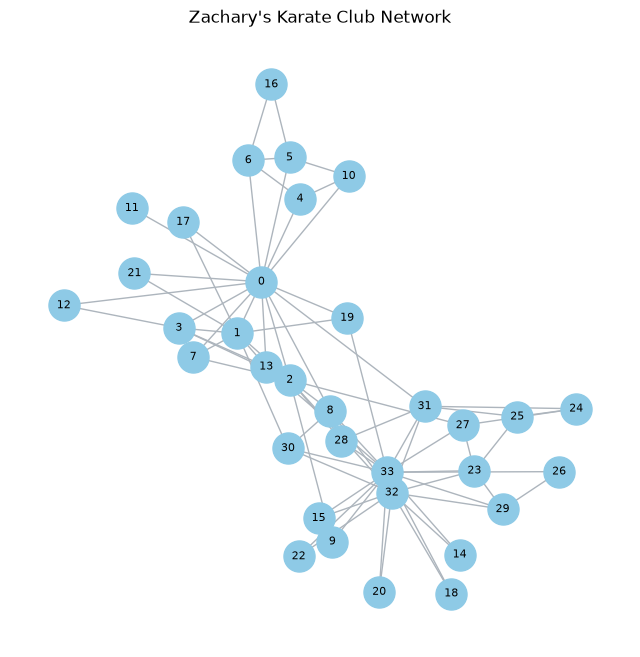

Number of nodes: 34
Number of edges: 78
Five highest-degree nodes:
Node 33: degree 17
Node 0: degree 16
Node 32: degree 12
Node 2: degree 10
Node 1: degree 9


In [9]:
# 1.3.4
G = nx.karate_club_graph()

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_color="#8ecae6",
    edge_color="#adb5bd",
    node_size=500,
    font_size=8,
)
plt.title("Zachary's Karate Club Network")
plt.axis("off")
plt.show()

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
top_five_nodes = sorted(G.degree, key=lambda item: item[1], reverse=True)[:5]

print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print("Five highest-degree nodes:")
for node, degree in top_five_nodes:
    print(f"Node {node}: degree {degree}")

In [10]:
list(G.edges(data=True))
i = 0
for edge in G.edges(data=True):
    if edge[0] == 33 or edge[1] == 33:
        i+=1
print(i)

17


[[0 1 1 0]
 [1 0 1 0]
 [0 0 0 1]
 [0 1 0 0]]


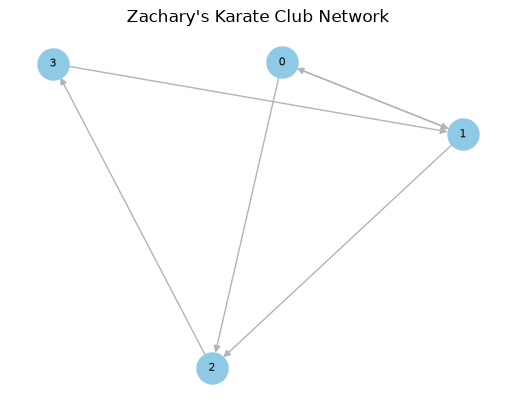

In-degrees: dict_values([1, 2, 2, 1])
Adjacency matrix row sum: [1 2 2 1]

Out-degrees: dict_values([2, 2, 1, 1])
Adjacency matrix column sum: [2 2 1 1]


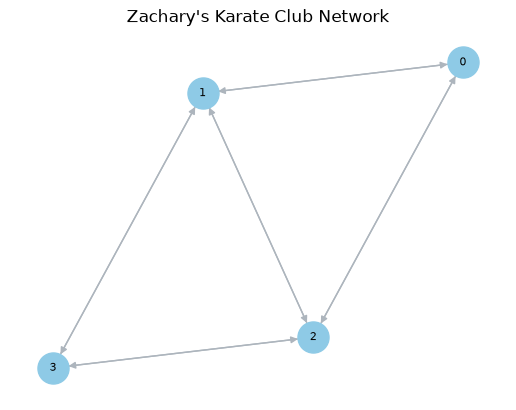

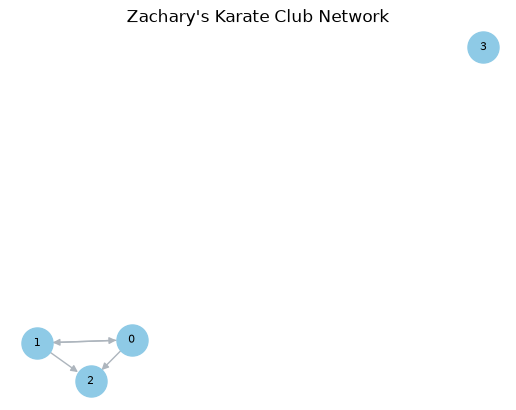

In [11]:
# 1.3.4
## n = 5

# Built by hand
adj_mat = np.zeros((4, 4), dtype=int)
adj_mat[0, 1] = adj_mat[1, 0] = 1
adj_mat[0, 2] = 1
adj_mat[1, 2] = 1
adj_mat[2, 3] = adj_mat[3, 1] = 1

print(adj_mat)

own_graph = nx.from_numpy_array(adj_mat, create_using=nx.DiGraph)
nx.draw_networkx(
    own_graph,
    arrows=True,
    with_labels=True,
    node_color="#8ecae6",
    edge_color="#adb5bd",
    node_size=500,
    font_size=8,
)
plt.title("Zachary's Karate Club Network")
plt.axis("off")
plt.show()

# In degree vs adjacency rows
print(f"In-degrees: {dict(own_graph.in_degree()).values()}")
print(f"Adjacency matrix row sum: {np.sum(adj_mat, axis=0)}")

print()
# Out degree vs adjacency columns
print(f"Out-degrees: {dict(own_graph.out_degree()).values()}")
print(f"Adjacency matrix column sum: {np.sum(adj_mat, axis=1)}")

## A + A^T - clip at 1
sym_adj_mat = np.clip(adj_mat + adj_mat.T, a_min=0, a_max=1)

own_graph = nx.from_numpy_array(sym_adj_mat, create_using=nx.DiGraph)
nx.draw_networkx(
    own_graph,
    arrows=True,
    with_labels=True,
    node_color="#8ecae6",
    edge_color="#adb5bd",
    node_size=500,
    font_size=8,
)
plt.title("Zachary's Karate Club Network")
plt.axis("off")
plt.show()


adj_mat[0,0] = 1
adj_mat[2, 3] = adj_mat[3, 1] = 0
own_graph = nx.from_numpy_array(adj_mat, create_using=nx.DiGraph)
nx.draw_networkx(
    own_graph,
    arrows=True,
    with_labels=True,
    node_color="#8ecae6",
    edge_color="#adb5bd",
    node_size=500,
    font_size=8,
)
plt.title("Zachary's Karate Club Network")
plt.axis("off")
plt.show()

In [12]:
from pathlib import Path
import csv

base_dir = Path("/home/borkeren/Desktop/SocialGraphs/Week1")
node_file = base_dir / "week1_nodes.tsv"
edge_file = base_dir / "week1_edges.tsv"


def read_tsv_rows(path, header_prefix):
    lines = path.read_text(encoding="utf-8").splitlines()
    header_index = next(i for i, line in enumerate(lines) if line.lstrip("# ").startswith(header_prefix))
    cleaned_lines = [lines[header_index].lstrip("# ").strip()]
    cleaned_lines.extend(line for line in lines[header_index + 1:] if line.strip() and not line.startswith("#"))
    return list(csv.DictReader(cleaned_lines, delimiter="\t"))


node_rows = read_tsv_rows(node_file, "node_id\t")
edge_rows = read_tsv_rows(edge_file, "source\t")

node_ids = [row["node_id"] for row in node_rows]
edges = [(row["source"], row["target"]) for row in edge_rows]

G_directed = nx.DiGraph()
G_directed.add_nodes_from(node_ids)
G_directed.add_edges_from(edges)

print(G_directed)

G_undirected = nx.Graph()
G_undirected.add_nodes_from(node_ids)
G_undirected.add_edges_from(edges)


def report_graph(name, graph):
    m = graph.number_of_edges()
    avg_degree = sum(dict(graph.degree()).values()) / graph.number_of_nodes()
    print(f"{name} graph")
    print(f"m = {m}")
    print(f"average degree = {avg_degree:.2f}")
    print()


report_graph("Directed", G_directed)
report_graph("Undirected", G_undirected)

print("Edge count differs, and is higher in the directed case. \
This is because the directed graph counts edges in both directions, \
while the undirected graph counts them only once. in + out is higher, \
than in undirected case. A reciprocal edge is counted twice in the directed case!")

DiGraph with 303 nodes and 1784 edges
Directed graph
m = 1784
average degree = 11.78

Undirected graph
m = 1434
average degree = 9.47

Edge count differs, and is higher in the directed case. This is because the directed graph counts edges in both directions, while the undirected graph counts them only once. in + out is higher, than in undirected case. A reciprocal edge is counted twice in the directed case!


In [ ]:
from collections import Counter
import math

from ipywidgets import widgets
from IPython.display import display

node_name = {row["node_id"]: row["name"] for row in node_rows}


def degree_distribution(degree_view):
    counts = Counter(dict(degree_view).values())
    ks = np.array(sorted(counts), dtype=float)
    frequencies = np.array([counts[int(k)] for k in ks], dtype=float) / len(node_ids)
    return ks + 1, frequencies


def binned_distribution(degree_view):
    counts = Counter(dict(degree_view).values())
    total = len(node_ids)
    max_u = max((k + 1) for k in counts)

    xs = []
    ys = []
    left = 1
    while left <= max_u:
        if left < 8:
            right = left + 1
        else:
            right = left * 2

        count = sum(c for k, c in counts.items() if left <= (k + 1) < right)
        if count > 0:
            width = right - left
            x_center = math.sqrt(left * (right - 1))
            y_density = count / (total * width)
            xs.append(x_center)
            ys.append(y_density)

        left = right

    return np.array(xs), np.array(ys)


in_ks, in_freq = degree_distribution(G_directed.in_degree())
out_ks, out_freq = degree_distribution(G_directed.out_degree())

in_bin_x, in_bin_y = binned_distribution(G_directed.in_degree())
out_bin_x, out_bin_y = binned_distribution(G_directed.out_degree())


def print_leaderboard(label, degree_view):
    top_five = sorted(degree_view, key=lambda item: item[1], reverse=True)[:5]
    print(f"{label} top five characters:")
    for node_id, degree in top_five:
        print(f"- {node_name.get(node_id, node_id)} ({node_id}): {degree}")
    print()


print_leaderboard("In-degree", G_directed.in_degree())
print_leaderboard("Out-degree", G_directed.out_degree())
print("Leaderboard check: compare the printed names and counts against the explorable's leaderboard.")

scale_toggle = widgets.ToggleButtons(
    options=[("Linear-linear", "linear"), ("Log-log", "log")],
    value="linear",
    description="Scale:",
    button_style="",
)

binned_toggle = widgets.ToggleButtons(
    options=[("Hide binned", False), ("Show binned", True)],
    value=True,
    description="Binning:",
    button_style="",
)

output = widgets.Output()


def draw_distributions(change=None):
    scale_mode = scale_toggle.value
    show_binned = binned_toggle.value
    with output:
        output.clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        for axis, ks, frequencies, bin_x, bin_y, title in [
            (axes[0], in_ks, in_freq, in_bin_x, in_bin_y, "In-degree distribution"),
            (axes[1], out_ks, out_freq, out_bin_x, out_bin_y, "Out-degree distribution"),
        ]:
            axis.plot(ks, frequencies, marker="o", linestyle="", color="C0", label="raw")
            if show_binned:
                axis.plot(bin_x, bin_y, marker="s", linestyle="-", color="C3", linewidth=2, label="binned")
            axis.set_title(
                f"{title} ({'log-log' if scale_mode == 'log' else 'linear-linear'})"
            )
            axis.set_xlabel("k + 1 (shifted so isolates stay on the log axis)")
            axis.set_ylabel("P(k)")
            axis.legend()
            if scale_mode == "log":
                axis.set_xscale("log")
                axis.set_yscale("log")

        plt.tight_layout()
        plt.show()


scale_toggle.observe(draw_distributions, names="value")
binned_toggle.observe(draw_distributions, names="value")

display(scale_toggle, binned_toggle, output)
draw_distributions()

In-degree top five characters:
- Spider-Man (Spider-Man): 106
- Hulk (Hulk): 64
- Wolverine (character) (Wolverine_(character)): 60
- Doctor Strange (Doctor_Strange): 50
- Deadpool (Deadpool): 33

Out-degree top five characters:
- Betsy Braddock (Betsy_Braddock): 28
- Cloak and Dagger (characters) (Cloak_and_Dagger_(characters)): 24
- Adam Warlock (Adam_Warlock): 22
- Venom (character) (Venom_(character)): 21
- She-Hulk (She-Hulk): 20

Leaderboard check: compare the printed names and counts against the explorable's leaderboard.


ToggleButtons(description='Scale:', options=(('Linear-linear', 'linear'), ('Log-log', 'log')), value='linear')

ToggleButtons(description='Binning:', index=1, options=(('Hide binned', False), ('Show binned', True)), value=…

Output()

In [ ]:
from collections import Counter

specimen_toggle = widgets.ToggleButtons(
    options=[
        ("Exponential vs power law", "specimens"),
        ("Real in-degree + specimens", "real"),
    ],
    value="specimens",
    description="View:",
    button_style="",
)

axis_toggle = widgets.ToggleButtons(
    options=[
        ("Linear-linear", "linear_linear"),
        ("Linear-log", "linear_log"),
        ("Log-linear", "log_linear"),
        ("Log-log", "log_log"),
    ],
    value="log_log",
    description="Axes:",
    button_style="",
)

output2 = widgets.Output()
rng = np.random.default_rng(42)
exponential_samples = rng.exponential(scale=8, size=100_000)
power_law_samples = 1 + rng.pareto(1.5, size=100_000)


def empirical_density(samples, bins):
    hist, edges = np.histogram(samples, bins=bins, density=True)
    centers = np.sqrt(edges[:-1] * edges[1:])
    return centers, hist


def raw_degree_distribution(degree_view):
    counts = Counter(dict(degree_view).values())
    degrees = np.array(sorted(counts), dtype=float)
    probs = np.array([counts[int(k)] for k in degrees], dtype=float) / len(node_ids)
    return degrees + 1, probs


sample_max = max(exponential_samples.max(), power_law_samples.max())
common_edges = np.geomspace(1, sample_max + 1, 60)
exp_x, exp_y = empirical_density(exponential_samples + 1, common_edges)
pow_x, pow_y = empirical_density(power_law_samples + 1, common_edges)
real_in_x, real_in_y = raw_degree_distribution(G_directed.in_degree())


def style_axes(ax, mode):
    if mode in ("log_linear", "log_log"):
        ax.set_xscale("log")
    if mode in ("linear_log", "log_log"):
        ax.set_yscale("log")
    ax.set_xlabel("k + 1")
    ax.set_ylabel("P(k)")


def draw_specimens(mode):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(exp_x, exp_y, label="Exponential samples", color="C1")
    ax.plot(pow_x, pow_y, label="Power-law samples", color="C2")
    style_axes(ax, mode)
    ax.set_title("Two synthetic distributions")
    ax.legend()
    plt.tight_layout()
    plt.show()


def draw_real_and_specimens(mode):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(exp_x, exp_y, label="Exponential samples", color="C1", alpha=0.75)
    ax.plot(pow_x, pow_y, label="Power-law samples", color="C2", alpha=0.75)
    ax.plot(real_in_x, real_in_y, label="Real in-degree", color="C0", linewidth=2)
    style_axes(ax, mode)
    ax.set_title("Real in-degree vs synthetic specimens")
    ax.legend()
    plt.tight_layout()
    plt.show()



def render(change=None):
    with output2:
        output2.clear_output(wait=True)
        mode = axis_toggle.value
        if specimen_toggle.value == "specimens":
            draw_specimens(mode)
        else:
            draw_real_and_specimens(mode)
        print("Expect the power-law sample to straighten on log-log axes and the exponential sample to straighten on linear-log axes.")
        print("The real in-degree should look more like the power law on log-log axes, especially in the tail.")


specimen_toggle.observe(render, names="value")
axis_toggle.observe(render, names="value")

display(specimen_toggle, axis_toggle, output2)
render()

ToggleButtons(description='View:', options=(('Exponential vs power law', 'specimens'), ('Real in-degree + spec…

ToggleButtons(description='Axes:', index=3, options=(('Linear-linear', 'linear_linear'), ('Linear-log', 'linea…

Output()